<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 18: Non-Parametric Statistics and Tests
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 17, 18

**Topic:** This notebook demonstrates core concepts in non-parametric statistics, including goodness-of-fit tests, resampling techniques, contingency tables, and rank-based tests for non-normal data.

## 1. The Danger of Assuming Normality
Parametric tests (like t-tests and ANOVAs) rely on the mathematical properties of a normal, bell-shaped distribution. However, when a population is grossly non-normal—such as a bimodal distribution—the actual range of sample means will behave differently than the normal model predicts. Because this expected range is wrong, any judgment about statistical significance (the p-value) can be highly misleading.

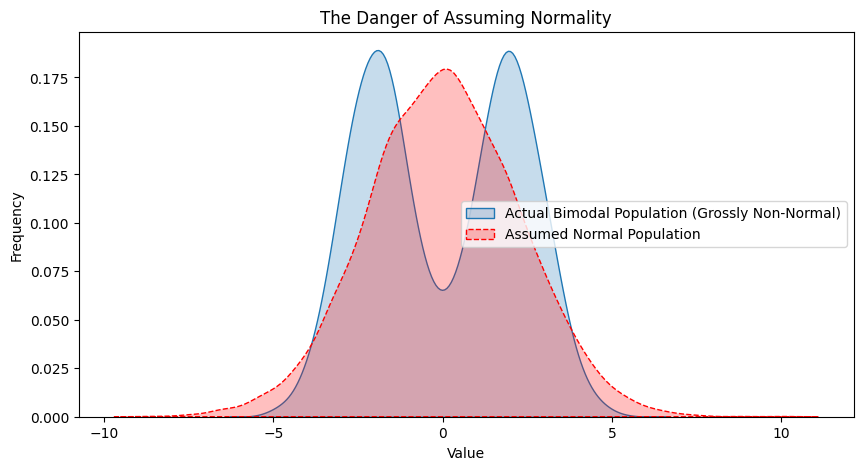

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Generate a grossly non-normal (bimodal) distribution
dist1 = np.random.normal(loc=-2, scale=1, size=5000)
dist2 = np.random.normal(loc=2, scale=1, size=5000)
bimodal_data = np.concatenate([dist1, dist2])

# Generate a standard normal distribution for comparison
normal_data = np.random.normal(loc=0, scale=2.24, size=10000)

plt.figure(figsize=(10, 5))
sns.kdeplot(bimodal_data, fill=True, label='Actual Bimodal Population (Grossly Non-Normal)')
sns.kdeplot(normal_data, fill=True, label='Assumed Normal Population', linestyle="--", color="red")
plt.title('The Danger of Assuming Normality')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 2. Chi-Squared Goodness of Fit Test
The Chi-Square Goodness of Fit test compares results obtained from a sample (observed frequencies) against a theoretical prediction (expected frequencies). For example, if the natural proportion of left-coiling foraminifera is expected to be 10%, but a sample of 20 yields 4 left-rotated ones, we calculate the chi-square statistic to see if the observation deviates significantly from the expectation.

Chi-Square Statistic: 2.22
Degrees of Freedom: 1
P-value: 0.1360


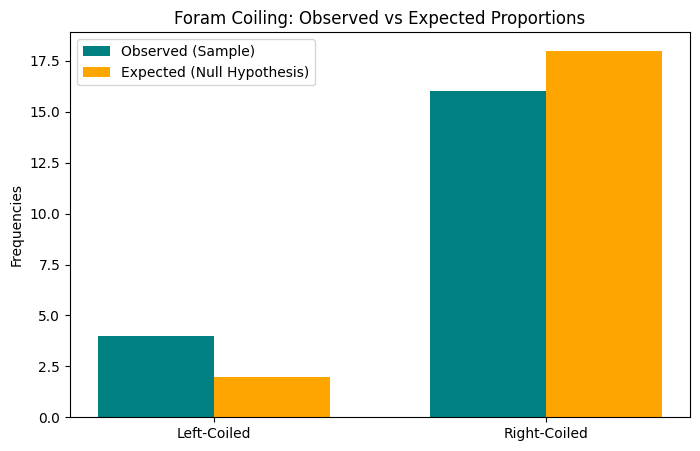

In [2]:
# Chi-Square Goodness of Fit Calculation for Foram Coiling
observed_forams = np.array([4, 16]) # 4 left, 16 right
expected_forams = np.array([2, 18]) # 10% of 20 = 2 left, 90% of 20 = 18 right

chi_square_stat, p_value = stats.chisquare(f_obs=observed_forams, f_exp=expected_forams)

print(f"Chi-Square Statistic: {chi_square_stat:.2f}")
print(f"Degrees of Freedom: {len(observed_forams) - 1}")
print(f"P-value: {p_value:.4f}")

# Visualization of Observed vs Expected Frequencies
labels = ['Left-Coiled', 'Right-Coiled']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, observed_forams, width, label='Observed (Sample)', color='teal')
ax.bar(x + width/2, expected_forams, width, label='Expected (Null Hypothesis)', color='orange')

ax.set_ylabel('Frequencies')
ax.set_title('Foram Coiling: Observed vs Expected Proportions')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

## 3. Small Sample Sizes and Monte Carlo Simulations
When expected frequencies are very small, calculated statistics can become inflated and inaccurate. To solve this, researchers use Randomization Tests and Monte Carlo simulations, which rely on computer-generated random sampling rather than fixed mathematical curves.

A classic illustration of Monte Carlo methods involves estimating the value of Pi (π) by randomly placing data points inside a square and checking the ratio of points that land within an inscribed circle.

Number of points simulated: 10000
Estimated value of Pi: 3.13280


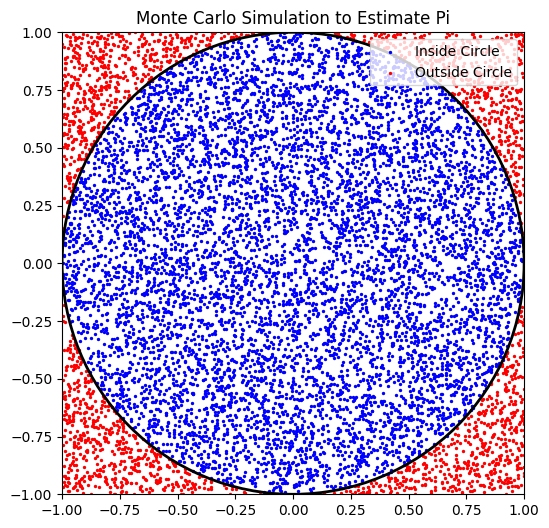

In [6]:
# Monte Carlo Simulation to Estimate Pi
n_points = 10000
x_rand = np.random.uniform(-1, 1, n_points)
y_rand = np.random.uniform(-1, 1, n_points)

# Check if points are inside the inscribed circle (x^2 + y^2 <= 1)
inside_circle = (x_rand**2 + y_rand**2) <= 1
pi_estimate = 4 * np.sum(inside_circle) / n_points

print(f"Number of points simulated: {n_points}")
print(f"Estimated value of Pi: {pi_estimate:.5f}")

# Visualization of the Monte Carlo simulation
plt.figure(figsize=(6, 6))
plt.scatter(x_rand[inside_circle], y_rand[inside_circle], color='blue', s=2, label='Inside Circle')
plt.scatter(x_rand[~inside_circle], y_rand[~inside_circle], color='red', s=2, label='Outside Circle')

# Draw the circle boundary
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
plt.gca().add_patch(circle)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title('Monte Carlo Simulation to Estimate Pi')
plt.legend(loc="upper right")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

## 4. Cross-Validation and Bootstrapping
Bootstrapping is a computer-intensive resampling technique that estimates the distribution of a statistic by repeatedly drawing new samples *with replacement* directly from the original dataset. The primary advantage of bootstrapping is that it relies purely on your empirical data and completely ignores normal distribution requirements.

Original Sample Mean: 67.79
95% Confidence Interval (Bootstrapped): [41.68, 98.16]


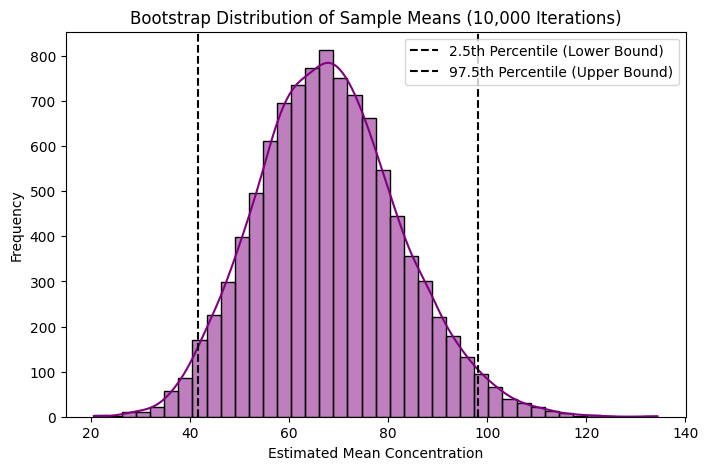

In [4]:
# Bootstrapping Example: Soil Zinc Concentrations
# Generating a mock dataset of 20 highly skewed measurements
original_sample = np.random.exponential(scale=45, size=20)

n_iterations = 10000
bootstrap_means = np.zeros(n_iterations)

for i in range(n_iterations):
    # Resample with replacement
    bootstrap_sample = np.random.choice(original_sample, size=len(original_sample), replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)

# Calculate Empirical 95% Confidence Interval
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Original Sample Mean: {np.mean(original_sample):.2f}")
print(f"95% Confidence Interval (Bootstrapped): [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualization of the Bootstrap Distribution
plt.figure(figsize=(8, 5))
sns.histplot(bootstrap_means, bins=40, kde=True, color='purple')
plt.axvline(ci_lower, color='black', linestyle='--', label='2.5th Percentile (Lower Bound)')
plt.axvline(ci_upper, color='black', linestyle='--', label='97.5th Percentile (Upper Bound)')
plt.title('Bootstrap Distribution of Sample Means (10,000 Iterations)')
plt.xlabel('Estimated Mean Concentration')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 5. Contingency Tables and Yates' Correction
When comparing proportions among two or more independent samples, data is often organized into contingency tables. For example, classifying wells across different locations based on the presence or absence of contamination.

When working with 2 x 2 contingency tables (exactly 1 degree of freedom), the continuous mathematical curves are often too sensitive for discrete data. **Yates' correction for continuity** is heavily recommended for 1-DOF tables to fix this bias by subtracting 0.5 from the absolute difference of observed and expected frequencies.

Chi-Square Statistic: 10.32
Degrees of Freedom: 2
P-value: 0.0058


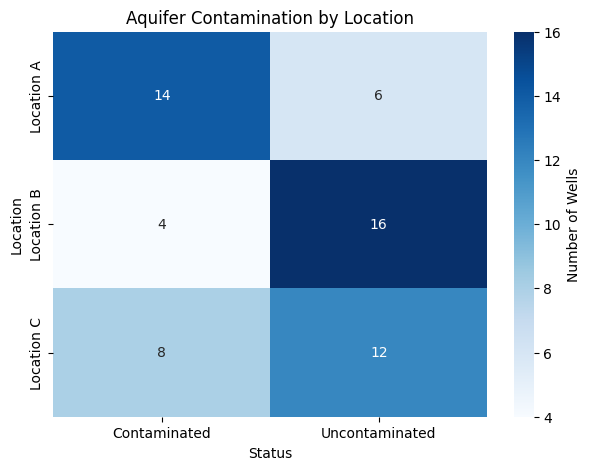

In [5]:
# Contingency Table Example: Contamination in Aquifers (3 Locations x 2 Statuses)
# Table Structure -> Rows: Loc A, B, C | Cols: Contaminated, Uncontaminated
contingency_table = np.array([
    [14, 6],  # Location A
    [4, 16],  # Location B
    [8, 12]   # Location C
])

# Perform Chi-Square Test for Independence
chi2_stat, p_val, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_val:.4f}")

# Visualization of the Contingency Table using a Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Contaminated", "Uncontaminated"],
            yticklabels=["Location A", "Location B", "Location C"],
            cbar_kws={'label': 'Number of Wells'})
plt.title('Aquifer Contamination by Location')
plt.ylabel('Location')
plt.xlabel('Status')
plt.show()